<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


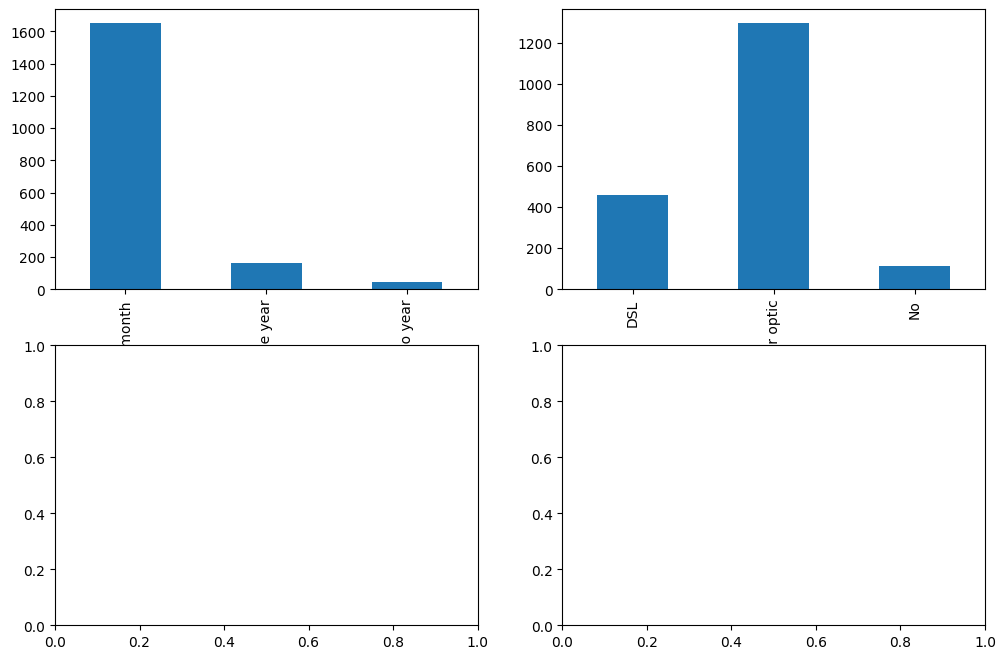

In [1]:
# 1. Load and explore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()
df.info()
df.describe()

# 2. Check churn distribution (CRITICAL - class imbalance)
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))
# Expected: ~73% No, ~27% Yes (imbalanced)

# 3. Visualize churn by top features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
df[df['Churn']=='Yes'].groupby('Contract').size().plot(kind='bar', ax=axes[0,0])
df[df['Churn']=='Yes'].groupby('InternetService').size().plot(kind='bar', ax=axes[0,1])
# ... more visualizations

# 4. Data cleaning
# - Drop irrelevant columns (customerID)
# - Handle missing values
# - Convert categorical to numeric (Contract, InternetService, etc.)
df_clean = df.drop('customerID', axis=1)
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# Save cleaned data
df_clean.to_csv('data/processed/churn_cleaned.csv', index=False)